In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.cluster import KMeans
import warnings
from IPython.display import display
warnings.filterwarnings('ignore')
np.random.seed(42)

# Visual theme
FEAR_C   = "#E84545"
GREED_C  = "#2ECC71"
EFEAR_C  = "#FF0000"
EGREED_C = "#00A550"
NEUT_C   = "#F0A500"
BG       = "#0F1117"
CARD     = "#1A1D2E"
TEXT     = "#E8E8E8"
ACCENT   = "#3A86FF"

plt.rcParams.update({
    "figure.facecolor": BG,   "axes.facecolor": CARD,
    "axes.edgecolor"  : "#333","axes.labelcolor": TEXT,
    "xtick.color": TEXT,      "ytick.color": TEXT,
    "text.color" : TEXT,      "legend.facecolor": CARD,
    "legend.edgecolor": "#444",
    "grid.color" : "#2A2D3E", "grid.linestyle": "--", "grid.alpha": 0.5,
    "font.size"  : 11,        "axes.titlesize": 13,
})

SENT_COLORS = {
    "Extreme Fear" : EFEAR_C,
    "Fear"         : FEAR_C,
    "Neutral"      : NEUT_C,
    "Greed"        : GREED_C,
    "Extreme Greed": EGREED_C,
}
print("Setup complete ✓")

Setup complete ✓


In [6]:
fg_raw = pd.read_csv("data/fear_greed_index.csv")
tr_raw = pd.read_csv("data/historical_data.csv")

print("=== Fear/Greed Dataset ===")
print(f"Shape : {fg_raw.shape[0]:,} rows × {fg_raw.shape[1]} cols")
display(fg_raw.head(3))

print("\n=== Trader Dataset ===")
print(f"Shape : {tr_raw.shape[0]:,} rows × {tr_raw.shape[1]} cols")
display(tr_raw.head(3))

=== Fear/Greed Dataset ===
Shape : 2,644 rows × 4 cols


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03



=== Trader Dataset ===
Shape : 211,224 rows × 16 cols


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


In [7]:
print("── Fear/Greed: missing values ──")
print(fg_raw.isnull().sum())
print(f"Duplicates: {fg_raw.duplicated().sum()}")

print("\n── Trader Data: missing values ──")
print(tr_raw.isnull().sum())
print(f"Duplicates: {tr_raw.duplicated().sum()}")

── Fear/Greed: missing values ──
timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicates: 0

── Trader Data: missing values ──
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Duplicates: 0


In [8]:
# Fear/Greed
fg = fg_raw.copy()
fg["date"] = pd.to_datetime(fg["date"])
fg["sentiment"] = fg["classification"]
fg["sent_binary"] = fg["classification"].map({
    "Extreme Fear": "Fear", "Fear": "Fear",
    "Neutral"     : "Neutral",
    "Greed"       : "Greed", "Extreme Greed": "Greed"
})

print("Sentiment distribution:")
print(fg["classification"].value_counts())

# Trader data
tr = tr_raw.copy()
tr["datetime"] = pd.to_datetime(tr["Timestamp IST"], dayfirst=True, errors="coerce")
tr["date"]     = tr["datetime"].dt.normalize()
tr.dropna(subset=["datetime"], inplace=True)

print(f"\nTrader date range: {tr['date'].min().date()} → {tr['date'].max().date()}")

# Merge
merged = tr.merge(
    fg[["date","value","sentiment","sent_binary"]],
    on="date", how="inner"
)
print(f"\nMerged shape: {merged.shape[0]:,} rows × {merged.shape[1]} cols")
print(merged["sentiment"].value_counts())

Sentiment distribution:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

Trader date range: 2023-05-01 → 2025-05-01

Merged shape: 211,218 rows × 21 cols
sentiment
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [9]:
merged.rename(columns={
    "Account"        : "account",
    "Coin"           : "coin",
    "Execution Price": "exec_price",
    "Size USD"       : "size_usd",
    "Side"           : "side",
    "Closed PnL"     : "closed_pnl",
    "Fee"            : "fee",
}, inplace=True)

# Daily per-trader metrics
daily = (
    merged.groupby(["date","account","sentiment","sent_binary","value"])
    .agg(
        daily_pnl   =("closed_pnl", "sum"),
        n_trades    =("closed_pnl", "count"),
        avg_size_usd=("size_usd", "mean"),
        total_fees  =("fee", "sum"),
        wins        =("closed_pnl", lambda x: (x > 0).sum()),
        long_trades =("side", lambda x: (x == "BUY").sum()),
        short_trades=("side", lambda x: (x == "SELL").sum()),
    )
    .reset_index()
)
daily["win_rate"]   = daily["wins"] / daily["n_trades"]
daily["long_ratio"] = daily["long_trades"] / daily["n_trades"]
daily["net_pnl"]    = daily["daily_pnl"] - daily["total_fees"]

# Per-trader overall stats
trader_stats = (
    merged.groupby("account")
    .agg(
        total_pnl   =("closed_pnl", "sum"),
        total_trades=("closed_pnl", "count"),
        avg_size    =("size_usd", "mean"),
        total_fees  =("fee", "sum"),
        wins        =("closed_pnl", lambda x: (x > 0).sum()),
    )
    .reset_index()
)
trader_stats["win_rate"] = trader_stats["wins"] / trader_stats["total_trades"]
trader_stats["net_pnl"]  = trader_stats["total_pnl"] - trader_stats["total_fees"]

print(f"Daily records : {len(daily):,}")
print(f"Unique traders: {trader_stats['account'].nunique():,}")
display(daily.head(3))

Daily records : 2,340
Unique traders: 32


,date,account,sentiment,sent_binary,value,daily_pnl,n_trades,avg_size_usd,total_fees,wins,long_trades,short_trades,win_rate,long_ratio,net_pnl
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,Greed,63,0.000000,3,159.000000,0.000000,0,3,0,0.000000,1.000000,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,Greed,75,0.000000,9,5556.203333,12.501455,0,7,2,0.000000,0.777778,-12.501455
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,Greed,72,-205.434737,11,10291.213636,28.300831,4,5,6,0.363636,0.454545,-233.735568


In [10]:
order = ["Extreme Fear","Fear","Neutral","Greed","Extreme Greed"]

perf = daily.groupby("sentiment")["daily_pnl"].agg(
    Mean="mean", Median="median", Std="std",
    Positive=lambda x: (x > 0).mean() * 100
).round(3).reindex(order)
perf.columns = ["Mean PnL ($)","Median PnL ($)","Std Dev ($)","% Profitable Days"]
print("Performance by Sentiment:")
display(perf)

# Statistical test
fear_pnl  = daily[daily["sent_binary"] == "Fear"]["daily_pnl"]
greed_pnl = daily[daily["sent_binary"] == "Greed"]["daily_pnl"]
t, p = stats.ttest_ind(fear_pnl, greed_pnl)
print(f"\nT-test Fear vs Greed: t={t:.3f}, p={p:.4f}")
print("→ Significant!" if p < 0.05 else "→ Not significant.")

Performance by Sentiment:


,Mean PnL ($),Median PnL ($),Std Dev ($),% Profitable Days
sentiment,,,,
Extreme Fear,4619.439,218.377,29534.839,60.000
Fear,5328.818,107.893,31659.772,60.476
Neutral,3438.619,167.552,17447.864,62.234
Greed,3318.101,158.215,30599.040,61.111
Extreme Greed,5161.923,418.320,27496.864,68.251



T-test Fear vs Greed: t=0.752, p=0.4518
→ Not significant.


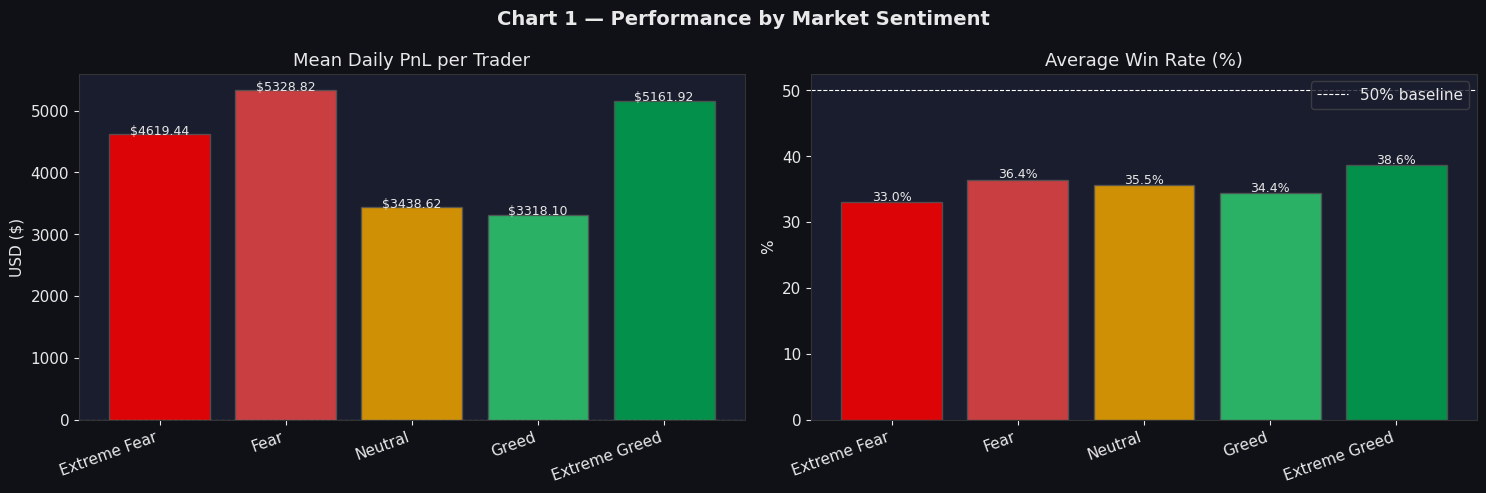

In [11]:
colors = [SENT_COLORS[s] for s in order]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Chart 1 — Performance by Market Sentiment", fontweight="bold", fontsize=14)

means = [daily[daily["sentiment"] == s]["daily_pnl"].mean() for s in order]
bars = axes[0].bar(order, means, color=colors, alpha=0.85, edgecolor="#555")
axes[0].axhline(0, color="white", linewidth=0.8, linestyle="--")
axes[0].set_title("Mean Daily PnL per Trader")
axes[0].set_ylabel("USD ($)")
axes[0].set_xticklabels(order, rotation=20, ha="right")
for bar, val in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + (0.3 if val >= 0 else -0.8),
                 f"${val:.2f}", ha="center", fontsize=9, color=TEXT)

wrs = [daily[daily["sentiment"] == s]["win_rate"].mean() * 100 for s in order]
bars2 = axes[1].bar(order, wrs, color=colors, alpha=0.85, edgecolor="#555")
axes[1].axhline(50, color="white", linewidth=0.8, linestyle="--", label="50% baseline")
axes[1].set_title("Average Win Rate (%)")
axes[1].set_ylabel("%")
axes[1].set_xticklabels(order, rotation=20, ha="right")
axes[1].legend()
for bar, val in zip(bars2, wrs):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f"{val:.1f}%", ha="center", fontsize=9, color=TEXT)

plt.tight_layout()
plt.savefig("chart/chart1_performance_by_sentiment.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

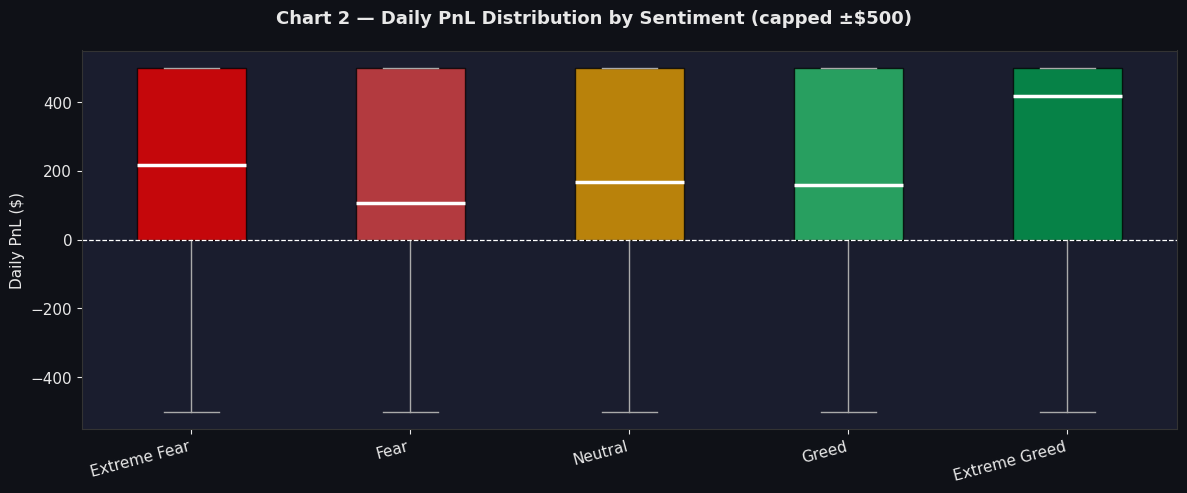

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Chart 2 — Daily PnL Distribution by Sentiment (capped ±$500)",
             fontweight="bold", fontsize=13)

plot_data = [daily[daily["sentiment"] == s]["daily_pnl"].clip(-500, 500).dropna() for s in order]
bp = ax.boxplot(
    plot_data, labels=order, patch_artist=True,
    medianprops=dict(color="white", linewidth=2.5),
    whiskerprops=dict(color="#aaa"), capprops=dict(color="#aaa"),
    flierprops=dict(markerfacecolor="#777", markersize=3, alpha=0.5),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.axhline(0, color="white", linewidth=0.9, linestyle="--")
ax.set_ylabel("Daily PnL ($)")
ax.set_xticklabels(order, rotation=15, ha="right")
plt.tight_layout()
plt.savefig("chart/chart2_pnl_boxplot.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

In [13]:
beh = daily.groupby("sentiment").agg(
    avg_trades    =("n_trades",     "mean"),
    avg_size_usd  =("avg_size_usd", "mean"),
    avg_long_ratio=("long_ratio",   "mean"),
).reindex(order).round(3)
print("Behavioural Metrics by Sentiment:")
display(beh)

Behavioural Metrics by Sentiment:


,avg_trades,avg_size_usd,avg_long_ratio
sentiment,,,
Extreme Fear,133.750,6773.464,0.532
Fear,98.154,8975.929,0.519
Neutral,100.229,6963.695,0.472
Greed,77.628,6427.867,0.472
Extreme Greed,76.030,5371.637,0.473


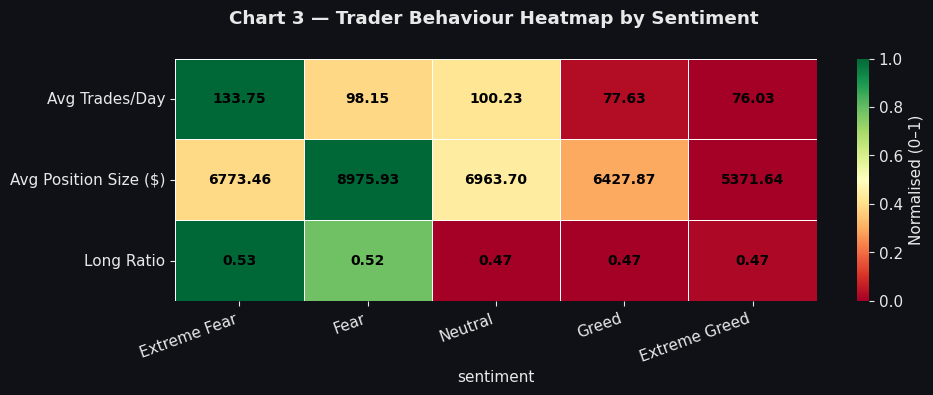

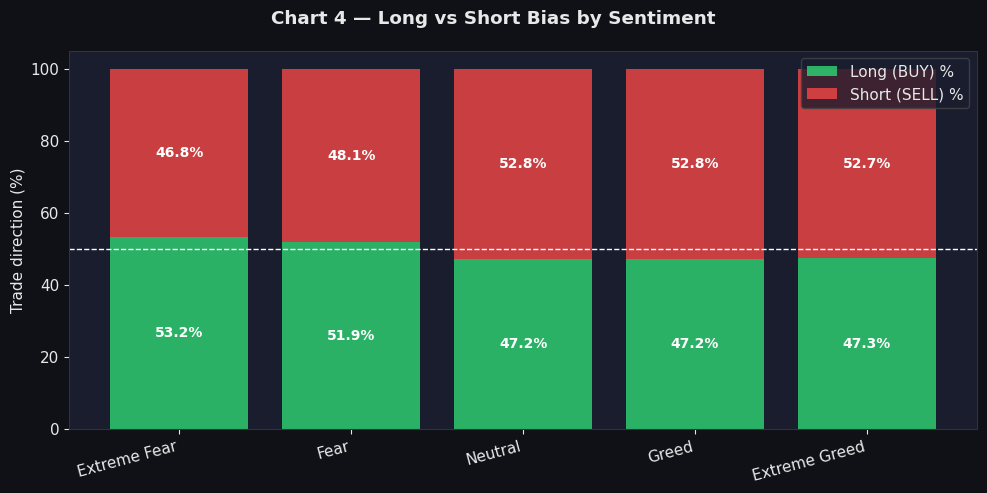

In [14]:
# Chart 3 — Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("Chart 3 — Trader Behaviour Heatmap by Sentiment", fontweight="bold")
beh_norm = (beh - beh.min()) / (beh.max() - beh.min())
beh_norm.columns = ["Avg Trades/Day","Avg Position Size ($)","Long Ratio"]
sns.heatmap(beh_norm.T, annot=beh.T.round(2), fmt=".2f", cmap="RdYlGn",
            linewidths=0.6, ax=ax, annot_kws={"size":10,"color":"black","weight":"bold"},
            cbar_kws={"label":"Normalised (0–1)"})
ax.set_xticklabels(order, rotation=20, ha="right")
plt.tight_layout()
plt.savefig("chart/chart3_behaviour_heatmap.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# Chart 4 — Long/Short
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Chart 4 — Long vs Short Bias by Sentiment", fontweight="bold")
long_pcts  = beh["avg_long_ratio"].values * 100
short_pcts = 100 - long_pcts
x = np.arange(len(order))
ax.bar(x, long_pcts,  color=GREED_C, alpha=0.85, label="Long (BUY) %")
ax.bar(x, short_pcts, bottom=long_pcts, color=FEAR_C, alpha=0.85, label="Short (SELL) %")
ax.axhline(50, color="white", linewidth=1, linestyle="--")
ax.set_xticks(x); ax.set_xticklabels(order, rotation=15, ha="right")
ax.set_ylabel("Trade direction (%)"); ax.legend()
for i, (lp, sp) in enumerate(zip(long_pcts, short_pcts)):
    ax.text(i, lp/2,      f"{lp:.1f}%", ha="center", va="center", fontsize=10, color="white", fontweight="bold")
    ax.text(i, lp + sp/2, f"{sp:.1f}%", ha="center", va="center", fontsize=10, color="white", fontweight="bold")
plt.tight_layout()
plt.savefig("chart/chart4_longshort_bias.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

In [15]:
# Frequency segment
freq = merged.groupby("account").size().rename("trade_count").reset_index()
q33, q66 = freq["trade_count"].quantile([0.33, 0.66])
freq["freq_segment"] = freq["trade_count"].apply(
    lambda n: "Infrequent" if n <= q33 else ("Frequent" if n > q66 else "Moderate")
)

# Performance segment
tp = merged.groupby("account")["closed_pnl"].sum()
p33, p66 = tp.quantile(0.33), tp.quantile(0.66)
perf_seg = tp.apply(
    lambda p: "Consistent Winner" if p >= p66 else ("Consistent Loser" if p < p33 else "Break-Even")
).rename("perf_segment").reset_index()

# Size segment
sz = merged.groupby("account")["size_usd"].mean().rename("avg_size_usd").reset_index()
s33, s66 = sz["avg_size_usd"].quantile(0.33), sz["avg_size_usd"].quantile(0.66)
sz["size_segment"] = sz["avg_size_usd"].apply(
    lambda s: "Small" if s <= s33 else ("Large" if s > s66 else "Medium")
)

# Merge all
trader_full = trader_stats.merge(freq[["account","freq_segment"]], on="account", how="left")
trader_full = trader_full.merge(perf_seg,                          on="account", how="left")
trader_full = trader_full.merge(sz[["account","size_segment"]],    on="account", how="left")

print(f"Trader profiles: {len(trader_full):,} unique traders")
display(trader_full.head(4))

Trader profiles: 32 unique traders


,account,total_pnl,total_trades,avg_size,total_fees,wins,win_rate,net_pnl,freq_segment,perf_segment,size_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,3818,16159.576734,7405.312304,1373,0.359612,1.592825e+06,Moderate,Consistent Winner,Large
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,7280,1653.226327,2729.837889,3223,0.442720,4.515548e+04,Frequent,Consistent Loser,Small
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,3809,8893.000898,9280.982850,1150,0.301917,-7.971717e+04,Moderate,Consistent Loser,Large
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,13311,507.626933,2218.367366,5838,0.438585,1.302464e+05,Frequent,Break-Even,Small


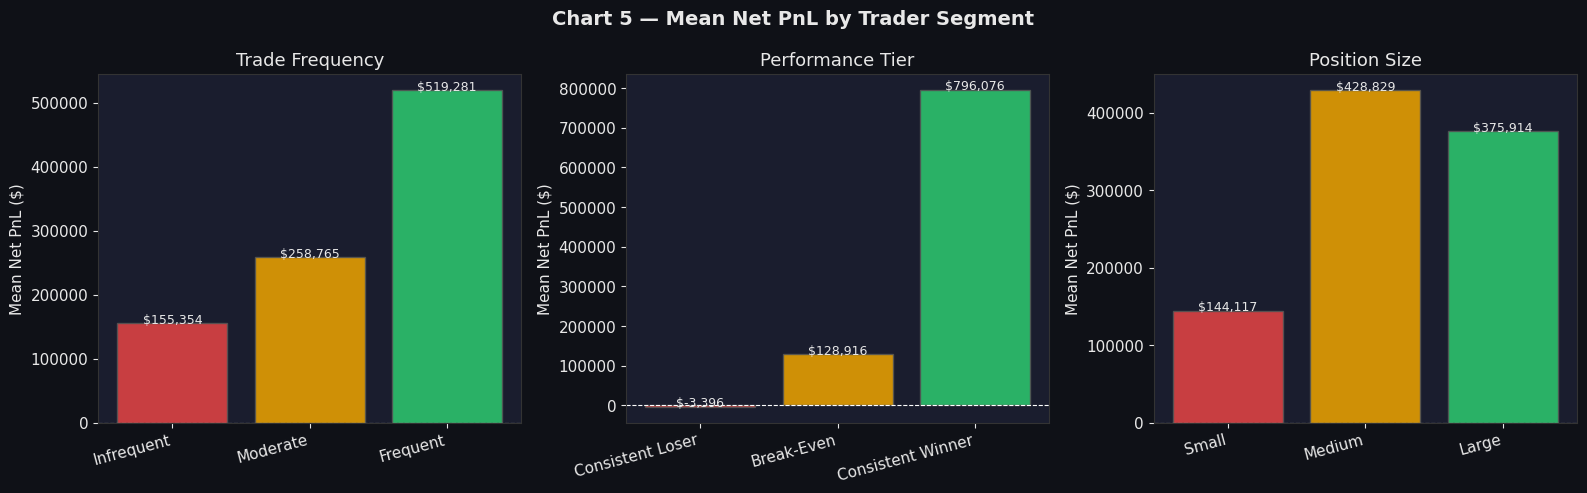

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Chart 5 — Mean Net PnL by Trader Segment", fontweight="bold", fontsize=14)

seg_info = [
    ("freq_segment",  ["Infrequent","Moderate","Frequent"],                   "Trade Frequency"),
    ("perf_segment",  ["Consistent Loser","Break-Even","Consistent Winner"],  "Performance Tier"),
    ("size_segment",  ["Small","Medium","Large"],                              "Position Size"),
]
clrs = [FEAR_C, NEUT_C, GREED_C]
for ax, (col, cats, title) in zip(axes, seg_info):
    vals = [trader_full[trader_full[col] == c]["net_pnl"].mean() for c in cats]
    bars = ax.bar(cats, vals, color=clrs, alpha=0.85, edgecolor="#555")
    ax.axhline(0, color="white", linewidth=0.8, linestyle="--")
    ax.set_title(title); ax.set_ylabel("Mean Net PnL ($)")
    ax.set_xticklabels(cats, rotation=15, ha="right")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + (50 if v >= 0 else -150),
                f"${v:,.0f}", ha="center", fontsize=9, color=TEXT)

plt.tight_layout()
plt.savefig("chart/chart5_segment_pnl.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

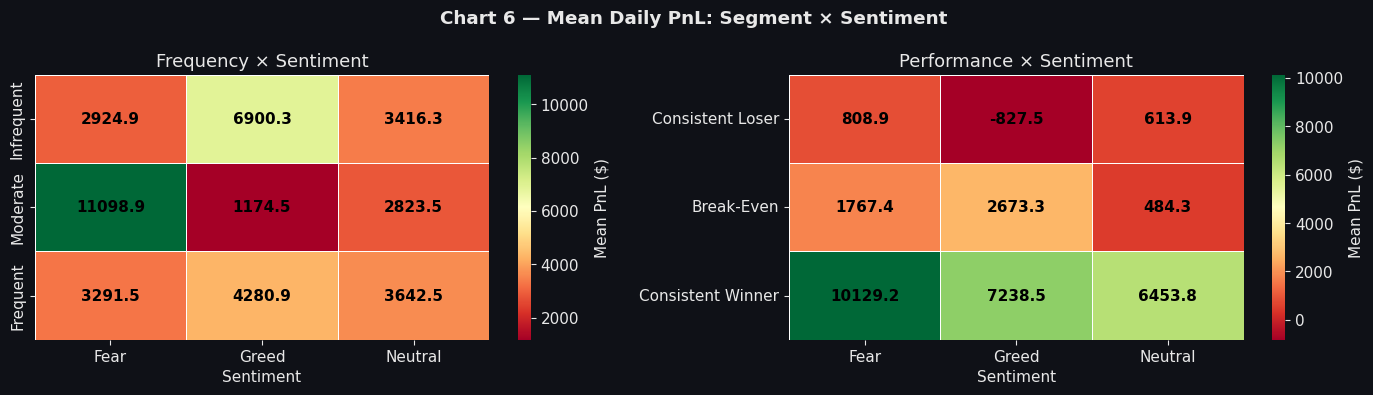

In [17]:
daily_seg = daily.merge(
    trader_full[["account","freq_segment","perf_segment","size_segment"]],
    on="account", how="left"
)

cross1 = daily_seg.groupby(["freq_segment","sent_binary"])["daily_pnl"].mean().unstack()
cross1 = cross1.reindex(["Infrequent","Moderate","Frequent"])

cross2 = daily_seg.groupby(["perf_segment","sent_binary"])["daily_pnl"].mean().unstack()
cross2 = cross2.reindex(["Consistent Loser","Break-Even","Consistent Winner"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Chart 6 — Mean Daily PnL: Segment × Sentiment", fontweight="bold")
for ax, data, title in zip(axes, [cross1, cross2],
                           ["Frequency × Sentiment","Performance × Sentiment"]):
    sns.heatmap(data, annot=True, fmt=".1f", cmap="RdYlGn", ax=ax,
                linewidths=0.5, annot_kws={"size":11,"color":"black","weight":"bold"},
                cbar_kws={"label":"Mean PnL ($)"})
    ax.set_title(title, color=TEXT)
    ax.set_xlabel("Sentiment"); ax.set_ylabel("")
plt.tight_layout()
plt.savefig("chart/chart6_cross_heatmap.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

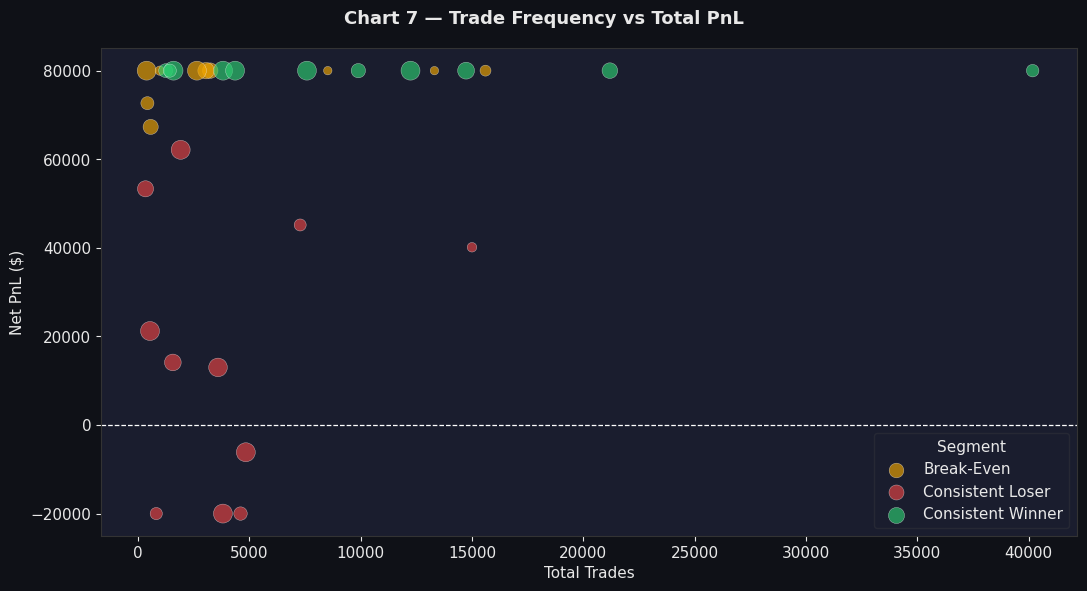

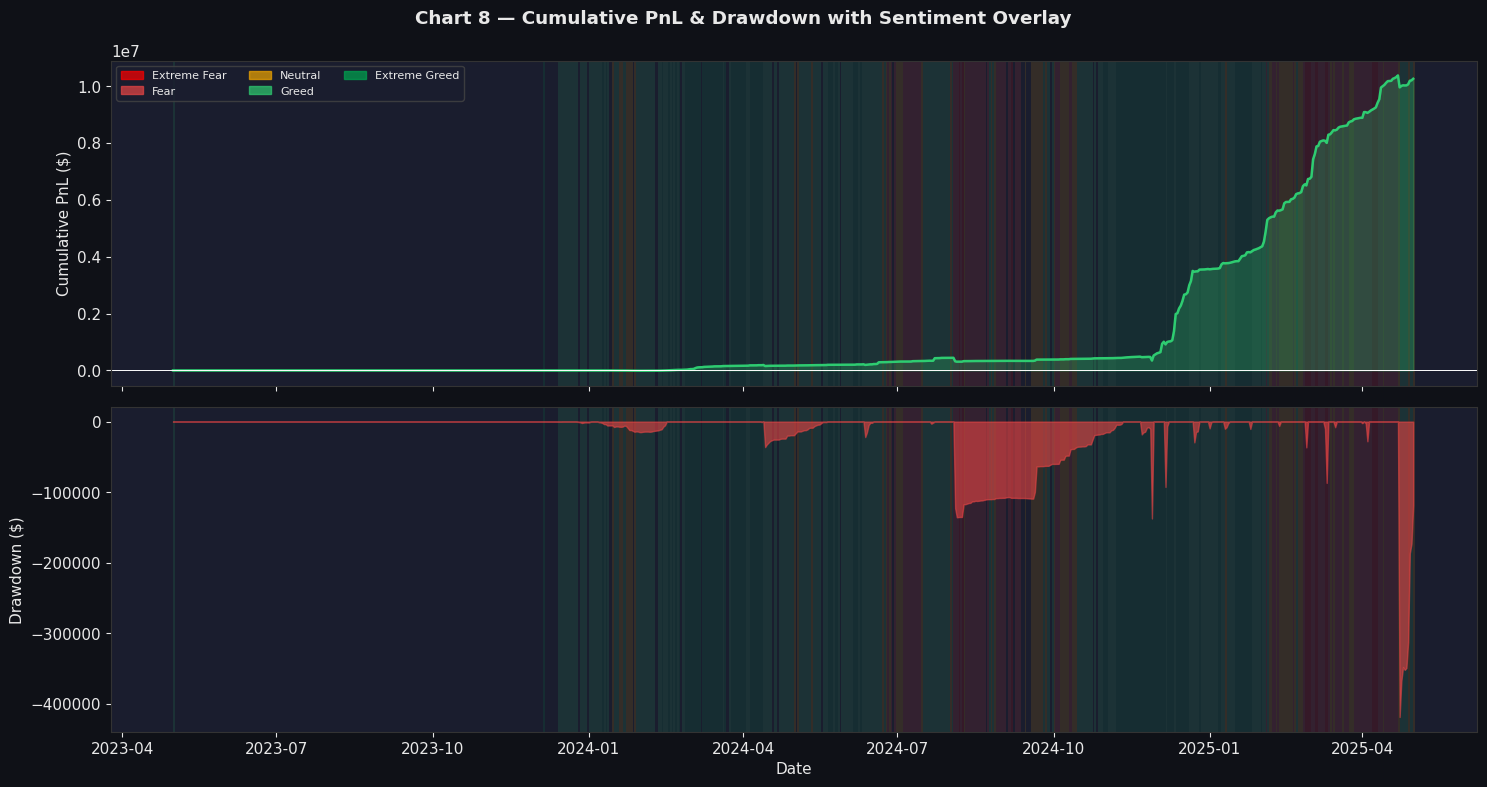

In [18]:
# Chart 7 — Scatter
fig, ax = plt.subplots(figsize=(11, 6))
fig.suptitle("Chart 7 — Trade Frequency vs Total PnL", fontweight="bold", fontsize=13)
seg_c = {"Consistent Winner": GREED_C, "Break-Even": NEUT_C, "Consistent Loser": FEAR_C}
for seg, grp in trader_full.groupby("perf_segment"):
    ax.scatter(grp["total_trades"], grp["net_pnl"].clip(-20000, 80000),
               s=grp["avg_size"].clip(upper=5000)/30 + 20,
               c=seg_c[seg], alpha=0.65, edgecolors="white", linewidths=0.3, label=seg)
ax.axhline(0, color="white", linewidth=0.9, linestyle="--")
ax.set_xlabel("Total Trades"); ax.set_ylabel("Net PnL ($)")
ax.legend(title="Segment", framealpha=0.3)
plt.tight_layout()
plt.savefig("chart/chart7_scatter_freq_pnl.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# Chart 8 — Timeline
agg = merged.groupby(["date","sentiment"])["closed_pnl"].sum().reset_index().sort_values("date")
agg["cum_pnl"]     = agg["closed_pnl"].cumsum()
agg["running_max"] = agg["cum_pnl"].cummax()
agg["drawdown"]    = agg["cum_pnl"] - agg["running_max"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle("Chart 8 — Cumulative PnL & Drawdown with Sentiment Overlay", fontweight="bold")
for _, row in agg.iterrows():
    c = SENT_COLORS.get(row["sentiment"], "#888")
    for axx in [ax1, ax2]:
        axx.axvspan(row["date"], row["date"] + pd.Timedelta(days=1), alpha=0.12, color=c, linewidth=0)
ax1.plot(agg["date"], agg["cum_pnl"], color=GREED_C, linewidth=1.8)
ax1.fill_between(agg["date"], agg["cum_pnl"], alpha=0.25, color=GREED_C)
ax1.axhline(0, color="white", linewidth=0.7)
ax1.set_ylabel("Cumulative PnL ($)")
patches = [mpatches.Patch(color=v, label=k, alpha=0.7) for k, v in SENT_COLORS.items()]
ax1.legend(handles=patches, loc="upper left", fontsize=8, ncol=3)
ax2.fill_between(agg["date"], agg["drawdown"], 0, color=FEAR_C, alpha=0.6)
ax2.set_ylabel("Drawdown ($)"); ax2.set_xlabel("Date")
plt.tight_layout()
plt.savefig("chart/chart8_drawdown_timeline.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

In [19]:
ml_df = daily_seg.copy()
ml_df["profitable"]    = (ml_df["daily_pnl"] > 0).astype(int)
ml_df["sentiment_num"] = ml_df["value"]

feat_cols = ["n_trades","avg_size_usd","win_rate","long_ratio","sentiment_num"]
ml_clean  = ml_df[feat_cols + ["profitable"]].dropna()

X = ml_clean[feat_cols]
y = ml_clean["profitable"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Loss Day","Profit Day"]))
print(f"AUC-ROC      : {roc_auc_score(y_test, y_prob):.4f}")
cv = cross_val_score(rf, X, y, cv=5, scoring="roc_auc")
print(f"5-Fold CV AUC: {cv.mean():.4f} ± {cv.std():.4f}")

Classification Report:
              precision    recall  f1-score   support

    Loss Day       0.97      0.87      0.92       175
  Profit Day       0.93      0.99      0.96       293

    accuracy                           0.94       468
   macro avg       0.95      0.93      0.94       468
weighted avg       0.94      0.94      0.94       468

AUC-ROC      : 0.9767
5-Fold CV AUC: 0.9754 ± 0.0159


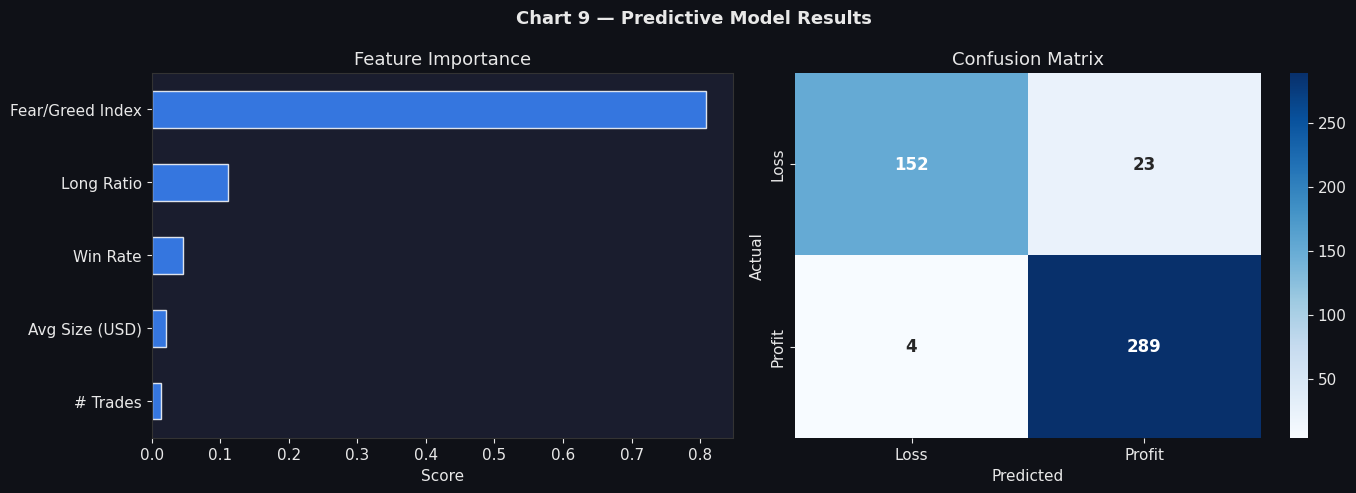

In [20]:
fi = pd.Series(rf.feature_importances_, index=feat_cols).sort_values()
fi.index = ["# Trades","Avg Size (USD)","Win Rate","Long Ratio","Fear/Greed Index"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chart 9 — Predictive Model Results", fontweight="bold", fontsize=13)

fi.plot(kind="barh", ax=axes[0], color=ACCENT, alpha=0.85, edgecolor="white")
axes[0].set_title("Feature Importance"); axes[0].set_xlabel("Score")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Loss","Profit"], yticklabels=["Loss","Profit"],
            annot_kws={"size":12,"weight":"bold"})
axes[1].set_title("Confusion Matrix")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("chart/chart9_model_results.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

In [21]:
cluster_feats = trader_full[["total_trades","avg_size","win_rate","net_pnl"]].copy().dropna()
scaler = StandardScaler()
X_sc   = scaler.fit_transform(cluster_feats)

km = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_feats["cluster"] = km.fit_predict(X_sc)

summary = cluster_feats.groupby("cluster").agg(
    count       =("total_trades","count"),
    avg_trades  =("total_trades","mean"),
    avg_size    =("avg_size","mean"),
    avg_win_rate=("win_rate","mean"),
    avg_pnl     =("net_pnl","mean"),
).round(1)
summary.index = [f"Cluster {i}" for i in summary.index]
print("Cluster Profiles:")
display(summary)

Cluster Profiles:


,count,avg_trades,avg_size,avg_win_rate,avg_pnl
Cluster 0,4,7119.0,22539.7,0.4,654729.8
Cluster 1,12,3664.8,2841.7,0.5,173962.9
Cluster 2,13,4819.7,4542.2,0.3,109267.8
Cluster 3,3,25369.7,2964.2,0.4,1293894.0


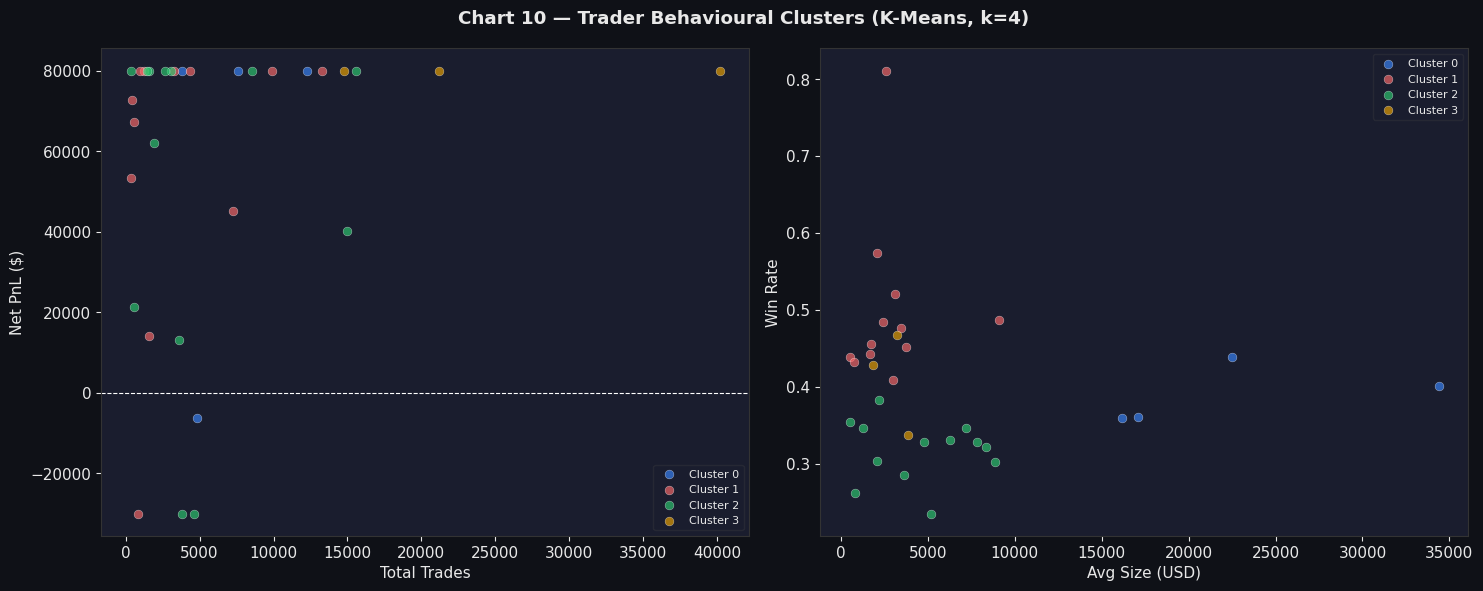

In [22]:
cluster_colors_map = ["#3A86FF","#FF6B6B","#2ECC71","#F0A500"]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Chart 10 — Trader Behavioural Clusters (K-Means, k=4)", fontweight="bold")

for ax, (xcol, ycol, xl, yl) in zip(axes, [
    ("total_trades","net_pnl", "Total Trades","Net PnL ($)"),
    ("avg_size","win_rate",    "Avg Size (USD)","Win Rate"),
]):
    for c, color in enumerate(cluster_colors_map):
        mask = cluster_feats["cluster"] == c
        yvals = cluster_feats.loc[mask, ycol]
        if ycol == "net_pnl": yvals = yvals.clip(-30000, 80000)
        ax.scatter(cluster_feats.loc[mask, xcol], yvals,
                   c=color, alpha=0.65, edgecolors="white", linewidths=0.3,
                   s=40, label=f"Cluster {c}")
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    if ycol == "net_pnl": ax.axhline(0, color="white", linewidth=0.8, linestyle="--")
    ax.legend(fontsize=8, framealpha=0.3)

plt.tight_layout()
plt.savefig("chart/chart10_clusters.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()